# Lab 7: Resampling Techniques — HPD Interval and Bayesian Bootstrap
# Virat Shrimali - 202303061

## Objective

This lab focuses on **simulation-based Bayesian inference** using resampling methods. The key goals are:

1. Understand the difference between:
   - Equal-tail credible intervals
   - Highest Posterior Density (HPD) intervals

2. Construct posterior distributions using:
   - Bayesian bootstrap (Dirichlet weights)

---

## Background

In Bayesian inference, we often work with a posterior distribution:
$$
\pi(\theta \mid x)
$$

Closed-form computation of summaries (mean, variance, intervals) is often difficult. Hence, we use:

- **Monte Carlo simulation**
- **Empirical approximations**

---

## Key Idea

Given samples:
$$
\theta_1, \theta_2, \dots, \theta_N \sim \pi(\theta \mid x)
$$

We approximate:

- Mean:
$$
\mathbb{E}[\theta] \approx \frac{1}{N} \sum_{i=1}^N \theta_i
$$

- Quantiles:
$$
\theta_p \approx \text{empirical quantile}
$$

- HPD interval:
Shortest interval covering given probability mass

# Problem 12: HPD Interval for a Skewed Posterior

We consider the posterior:
$$
\theta \sim \text{Beta}(2, 8)
$$

---

## Properties of Beta(2,8)

- Mean:
$$
\frac{2}{2+8} = 0.2
$$

- Mode:
$$
\frac{2-1}{2+8-2} = \frac{1}{8} = 0.125
$$

- Distribution is **right-skewed**

---

## Key Insight

For skewed distributions:

- Equal-tail interval:
$$
(\theta_{0.025}, \theta_{0.975})
$$

- HPD interval:
$$
(L,U) = \{\theta : \pi(\theta \mid x) > k\}
$$

These are **not equal**, because:
- Equal-tail ignores density
- HPD concentrates around high-density region

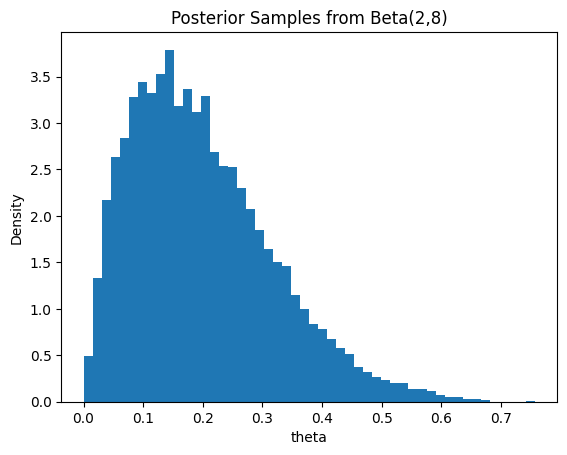

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

np.random.seed(42)

N = 10000
samples = beta.rvs(2, 8, size=N)

plt.hist(samples, bins=50, density=True)
plt.title("Posterior Samples from Beta(2,8)")
plt.xlabel("theta")
plt.ylabel("Density")
plt.show()

## Interpretation of Posterior Shape

- The distribution is **right-skewed**
- Mass concentrated near lower values
- Mode < mean

This implies:

- Symmetric intervals (equal-tail) are inefficient
- HPD interval will shift toward left (high-density region)

# Equal-Tail Interval

We compute:
$$
(\theta_{0.025}, \theta_{0.975})
$$

Using empirical quantiles:

$$
\hat{\theta}_{p} = \text{Quantile of samples at level } p
$$

---

## Interpretation

- Removes 2.5% probability from each tail
- Does not consider density shape

In [5]:
lower = np.quantile(samples, 0.025)
upper = np.quantile(samples, 0.975)

print("Equal-tail interval:", (lower, upper))
print("Equal-tail interval length:", (upper - lower))

Equal-tail interval: (np.float64(0.028501477173967307), np.float64(0.4784318749501325))
Equal-tail interval length: 0.4499303977761652


# HPD Interval

HPD interval is defined as:

$$
(L,U) = \arg\min_{interval} (U - L)
$$

subject to:
$$
P(L \le \theta \le U) = 0.95
$$

---

## Algorithm

1. Sort samples:
$$
\theta_{(1)} \le \dots \le \theta_{(N)}
$$

2. Consider intervals:
$$
(\theta_{(i)}, \theta_{(i + 0.95N)})
$$

3. Choose interval with minimum width:
$$
\min (U - L)
$$

In [4]:
sorted_samples = np.sort(samples)
interval_size = int(0.95 * N)

widths = sorted_samples[interval_size:] - sorted_samples[:N - interval_size]
min_idx = np.argmin(widths)

hpd_lower = sorted_samples[min_idx]
hpd_upper = sorted_samples[min_idx + interval_size]

print("HPD interval:", (hpd_lower, hpd_upper))
print("HPD interval length:", (hpd_upper - hpd_lower))

HPD interval: (np.float64(0.011375677496792977), np.float64(0.42914871719429837))
HPD interval length: 0.4177730396975054


# Comparison: Equal-Tail vs HPD

## Observations

1. HPD interval is **shorter**
2. HPD interval is **shifted toward high-density region**
3. Equal-tail interval includes low-density regions unnecessarily

---

## Reason

- Equal-tail is based on probability symmetry
- HPD is based on **density maximization**

For skewed distributions:
$$
\text{HPD} \neq \text{Equal-tail}
$$

## Visualization of Equal-Tail vs HPD

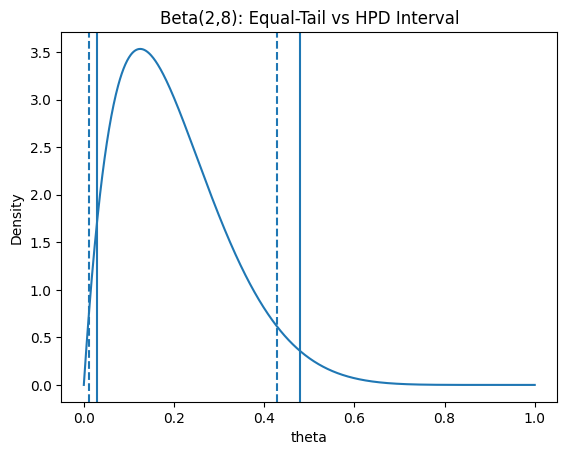

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# Posterior parameters
a, b = 2, 8

# Grid for density
x = np.linspace(0, 1, 1000)
pdf = beta.pdf(x, a, b)

# Simulate samples
np.random.seed(42)
N = 10000
samples = beta.rvs(a, b, size=N)

# Equal-tail interval
et_lower = np.quantile(samples, 0.025)
et_upper = np.quantile(samples, 0.975)

# HPD interval
sorted_samples = np.sort(samples)
interval_size = int(0.95 * N)

widths = sorted_samples[interval_size:] - sorted_samples[:N - interval_size]
min_idx = np.argmin(widths)

hpd_lower = sorted_samples[min_idx]
hpd_upper = sorted_samples[min_idx + interval_size]

# Plot
plt.figure()
plt.plot(x, pdf)

# Equal-tail (solid lines)
plt.axvline(et_lower)
plt.axvline(et_upper)

# HPD (dashed lines)
plt.axvline(hpd_lower, linestyle='--')
plt.axvline(hpd_upper, linestyle='--')

plt.title("Beta(2,8): Equal-Tail vs HPD Interval")
plt.xlabel("theta")
plt.ylabel("Density")

plt.show()

# 13 - Bayesian Bootstrap

We generate:
$$
x_1, \dots, x_{100} \sim \text{Exponential}(1)
$$

---

## Key Idea

Instead of resampling data:
- Assign weights:
$$
(w_1, \dots, w_n) \sim \text{Dirichlet}(1,\dots,1)
$$

- Construct weighted statistic:
$$
\hat{\theta}^* = \sum w_i x_i
$$

---

## Interpretation

- Classical bootstrap → resample observations
- Bayesian bootstrap → randomize probability weights

Mean: 0.9147480390388715
Variance: 0.8375454969016621


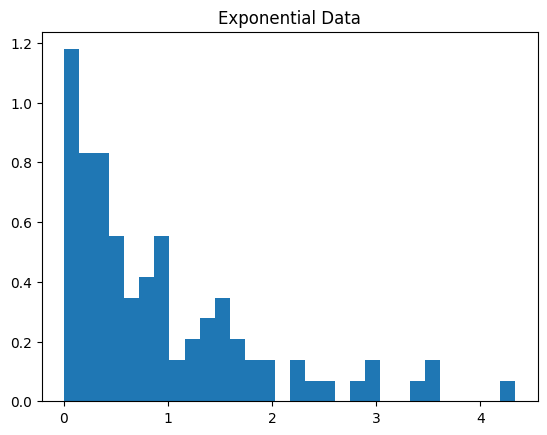

In [17]:
np.random.seed(42)

n = 100
data = np.random.exponential(scale=1, size=n)
print("Mean:", np.mean(data))
print("Variance:", np.var(data))
plt.hist(data, bins=30, density=True)
plt.title("Exponential Data")
plt.show()

## Data Characteristics

- Strong right skew
- Long tail
- Mean ≈ variance

---

## Implication

- Sampling variability is high
- Bootstrap methods are useful

# Dirichlet Weights

We generate:
$$
(w_1, \dots, w_n) \sim \text{Dirichlet}(1,\dots,1)
$$

---

## Property

$$
\sum_{i=1}^n w_i = 1
$$

This creates a **random probability distribution over data points**

In [8]:
weights = np.random.dirichlet(np.ones(n))

print("Sum of weights:", np.sum(weights))

Sum of weights: 1.0000000000000002


# Bayesian Bootstrap Estimator

We compute:
$$
\hat{\theta}^* = \sum_{i=1}^n w_i x_i
$$

---

## Monte Carlo Approximation

Repeat for B iterations:
$$
\hat{\theta}_1^*, \dots, \hat{\theta}_B^*
$$

This approximates the **posterior distribution of the mean**

In [9]:
B = 10000
theta_star = np.zeros(B)

for b in range(B):
    w = np.random.dirichlet(np.ones(n))
    theta_star[b] = np.sum(w * data)

# Posterior Analysis

We estimate:

- Posterior mean:
$$
\mathbb{E}[\theta] \approx \frac{1}{B} \sum \theta^*
$$

- Posterior variance:
$$
\text{Var}(\theta) \approx \text{sample variance}
$$

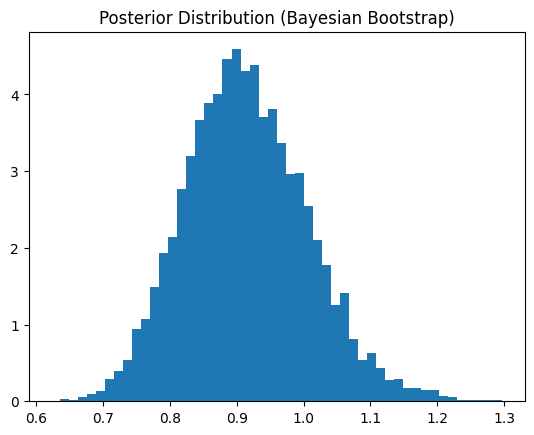

Posterior mean: 0.9148563119715456
Posterior variance: 0.00841339816599066


In [10]:
plt.hist(theta_star, bins=50, density=True)
plt.title("Posterior Distribution (Bayesian Bootstrap)")
plt.show()

print("Posterior mean:", np.mean(theta_star))
print("Posterior variance:", np.var(theta_star))

# HPD Interval (Bootstrap)

We apply same HPD logic:

1. Sort samples
2. Take shortest interval covering 95%

---

## Interpretation

This gives a **credible interval for the mean**

In [12]:
sorted_bs = np.sort(theta_star)
interval_size = int(0.95 * B)

widths = sorted_bs[interval_size:] - sorted_bs[:B - interval_size]
min_idx = np.argmin(widths)

hpd_bs = (sorted_bs[min_idx], sorted_bs[min_idx + interval_size])

print("Bootstrap HPD interval:", hpd_bs)
print("Bootstrap HPD interval length:", hpd_bs[1] - hpd_bs[0])

Bootstrap HPD interval: (np.float64(0.7451484251830198), np.float64(1.1011401433225614))
Bootstrap HPD interval length: 0.35599171813954156


# Final Conclusions

## Problem 12

- Equal-tail interval:
  - Based on quantiles
  - Ignores density

- HPD interval:
  - Shortest interval
  - Lies in high-density region

- For skewed distributions:
$$
\text{HPD} \neq \text{Equal-tail}
$$

---

## Problem 13

- Bayesian bootstrap:
  - Uses Dirichlet weights
  - Generates posterior over statistics

- Weighted mean:
$$
\hat{\theta}^* = \sum w_i x_i
$$

- Repeated sampling gives posterior distribution

---

## Key Takeaways

1. Simulation replaces analytical derivation
2. HPD captures density structure
3. Bayesian bootstrap models uncertainty via weights